# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     | Diego Dueñas Martín   |
| **Fecha**      |  8/03/2026 |
| **Expediente** |  751426 | 

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("Default.csv")
data.shape

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [4]:
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [5]:
data.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

El DataFrame contiene cuatro columnas:
- **default**: variable categórica (Yes/No) — indica si el cliente dejó de pagar su crédito.
- **student**: variable categórica (Yes/No) — indica si el cliente es estudiante.
- **balance**: variable numérica continua — saldo promedio mensual de la cuenta de crédito.
- **income**: variable numérica continua — ingreso anual del cliente.

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [6]:
data["default"] = data["default"].astype("category")

In [7]:
data["student"] = data["student"].astype("category")

In [8]:
data.dtypes

default    category
student    category
balance     float64
income      float64
dtype: object

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

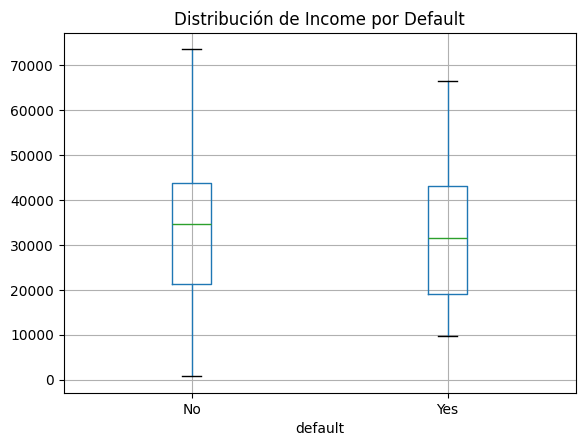

In [9]:
data.boxplot(column="income", by="default")
plt.suptitle("")
plt.title("Distribución de Income por Default")
plt.show()

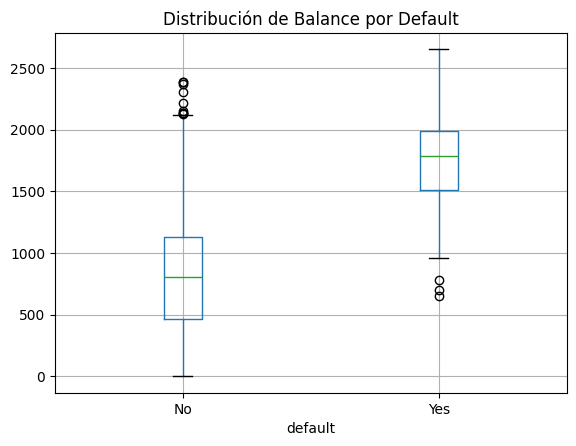

In [10]:
data.boxplot(column="balance", by="default")
plt.suptitle("")
plt.title("Distribución de Balance por Default")
plt.show()

# El balance de quienes dejaron de pagar es notablemente más alto.
# El ingreso, en cambio, no muestra diferencias claras entre los dos grupos.

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

In [11]:
# default es categórico (Yes/No); se convierte a 0/1 para usarlo como color
data["default_num"] = data["default"].cat.codes  # No=0, Yes=1

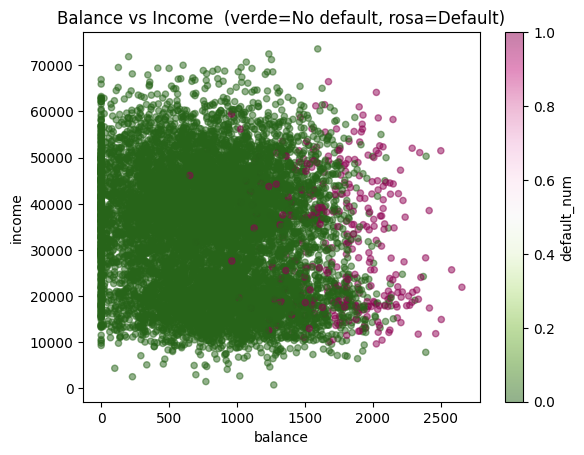

In [12]:
data.plot.scatter("balance", "income", c="default_num", colormap="PiYG_r", alpha=0.5)
plt.title("Balance vs Income  (verde=No default, rosa=Default)")
plt.show()

# Los clientes en default se agrupan en balances altos sin importar el nivel de ingreso,
# lo que refuerza que balance es el predictor más relevante de los dos.

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [ ]:
y = data["default"] == "Yes"
x = data[["balance"]]

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

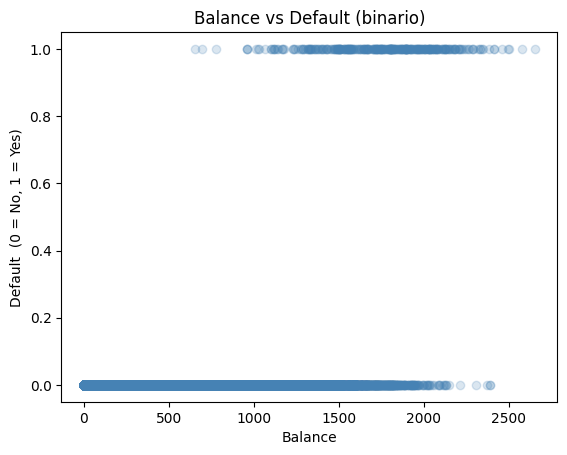

In [15]:
plt.scatter(data["balance"], y.astype(int), alpha=0.2, color="steelblue")
plt.xlabel("Balance")
plt.ylabel("Default  (0 = No, 1 = Yes)")
plt.title("Balance vs Default (binario)")
plt.show()

# A partir de ~1500 de balance prácticamente todos los casos son default=1.

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
print(f"β0 (intercepto): {model.intercept_[0]:.4f}")
print(f"β1 (balance):    {model.coef_[0][0]:.6f}")

β0 (intercepto): -10.6513
β1 (balance):    0.005499


Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [18]:
p_hat = model.predict_proba(x)[:, 1]

In [19]:
p_hat[:5]

array([0.00130568, 0.0021126 , 0.00859475, 0.00043444, 0.00177696])

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [20]:
variance = p_hat * (1 - p_hat)

In [21]:
variance[:5]

array([0.00130398, 0.00210813, 0.00852088, 0.00043425, 0.0017738 ])

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [22]:
V = np.diagflat(variance)

In [23]:
print("Dimensiones de V:", V.shape)

Dimensiones de V: (10000, 10000)


4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [ ]:
X_matrix = np.column_stack([np.ones(len(x)), x.values.flatten()])
cov = np.linalg.inv(X_matrix.T @ V @ X_matrix)

In [25]:
print("Matriz de covarianza:")
print(cov)

Matriz de covarianza:
[[ 1.30442757e-01 -7.81757265e-05]
 [-7.81757265e-05  4.85656561e-08]]


5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [26]:
se = np.sqrt(np.diag(cov))

In [27]:
print(f"SE β0: {se[0]:.4f}")
print(f"SE β1: {se[1]:.6f}")

SE β0: 0.3612
SE β1: 0.000220


Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [28]:
betas = np.array([model.intercept_[0], model.coef_[0][0]])
z_statistic = betas / se

In [29]:
print(f"z β0: {z_statistic[0]:.4f}")
print(f"z β1: {z_statistic[1]:.4f}")

z β0: -29.4913
z β1: 24.9524


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [30]:
from scipy.stats import norm

p_value = 2 * (1 - norm.cdf(abs(z_statistic)))

In [31]:
print(f"p-value β0: {p_value[0]:.4e}")
print(f"p-value β1: {p_value[1]:.4e}")

p-value β0: 0.0000e+00
p-value β1: 0.0000e+00


¿Es significativa la relación de los factores con la variable de respuesta?

Sí, la relación es estadísticamente significativa. El p-value de β1 (balance) es prácticamente 0, lo que indica evidencia muy fuerte de que el balance está asociado con la probabilidad de default. El p-value de β₀ también es significativo.

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [32]:
x_student = (data["student"] == "Yes").astype(int).values.reshape(-1, 1)

model_s = LogisticRegression()
model_s.fit(x_student, y)

print(f"β0 (intercepto): {model_s.intercept_[0]:.4f}")
print(f"β1 (student):    {model_s.coef_[0][0]:.4f}")

β0 (intercepto): -3.5026
β1 (student):    0.3962


In [33]:
p_hat_s  = model_s.predict_proba(x_student)[:, 1]
var_s    = p_hat_s * (1 - p_hat_s)
V_s      = np.diagflat(var_s)
X_s      = np.column_stack([np.ones(len(x_student)), x_student.flatten()])
cov_s    = np.linalg.inv(X_s.T @ V_s @ X_s)
se_s     = np.sqrt(np.diag(cov_s))

print(f"SE β0: {se_s[0]:.4f}")
print(f"SE β1: {se_s[1]:.4f}")

SE β0: 0.0707
SE β1: 0.1152


In [34]:
betas_s  = np.array([model_s.intercept_[0], model_s.coef_[0][0]])
z_s      = betas_s / se_s
p_val_s  = 2 * (1 - norm.cdf(abs(z_s)))

print(f"z β0: {z_s[0]:.4f}  |  p-value β0: {p_val_s[0]:.4e}")
print(f"z β1: {z_s[1]:.4f}  |  p-value β1: {p_val_s[1]:.4e}")

# β1 (student) es significativo (p-value < 0.05): ser estudiante está asociado con mayor
# probabilidad de default, probablemente porque los estudiantes suelen tener balances más altos.

z β0: -49.5684  |  p-value β0: 0.0000e+00
z β1: 3.4387  |  p-value β1: 5.8452e-04


## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [35]:
x_multi = data[["balance", "income"]].copy()
x_multi["student"] = (data["student"] == "Yes").astype(int)

model_m = LogisticRegression(max_iter=1000)
model_m.fit(x_multi, y)

labels  = ["β0 (intercepto)", "β1 (balance)", "β2 (income)", "β3 (student)"]
betas_m = np.concatenate([model_m.intercept_, model_m.coef_.flatten()])
for lbl, b in zip(labels, betas_m):
    print(f"{lbl}: {b:.6f}")

β0 (intercepto): -10.901807
β1 (balance): 0.005731
β2 (income): 0.000004
β3 (student): -0.612573


In [36]:
p_hat_m = model_m.predict_proba(x_multi)[:, 1]
var_m   = p_hat_m * (1 - p_hat_m)
V_m     = np.diagflat(var_m)
X_m     = np.column_stack([np.ones(len(x_multi)), x_multi.values])
cov_m   = np.linalg.inv(X_m.T @ V_m @ X_m)
se_m    = np.sqrt(np.diag(cov_m))

In [37]:
z_m     = betas_m / se_m
p_val_m = 2 * (1 - norm.cdf(abs(z_m)))

print(f"{'Factor':<20} {'β':>10} {'SE':>10} {'z':>8} {'p-value':>12}")
print("-" * 64)
for lbl, b, s, z, p in zip(labels, betas_m, se_m, z_m, p_val_m):
    print(f"{lbl:<20} {b:>10.4f} {s:>10.4f} {z:>8.2f} {p:>12.4e}")

# Al controlar por balance e income, el coeficiente de student se invierte (se vuelve negativo).
# Esto ocurre porque los estudiantes tienen balances promedio más altos; una vez que se controla
# por balance, ser estudiante en realidad reduce ligeramente la probabilidad de default.
# Balance sigue siendo el predictor más relevante del modelo.

Factor                        β         SE        z      p-value
----------------------------------------------------------------
β0 (intercepto)        -10.9018     0.4932   -22.11   0.0000e+00
β1 (balance)             0.0057     0.0002    24.74   0.0000e+00
β2 (income)              0.0000     0.0000     0.48   6.2936e-01
β3 (student)            -0.6126     0.2364    -2.59   9.5607e-03


¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

 1.– Filtrar correo no deseado: Si un mensaje legitimo se clasifica como spam (FP), el usuario puede perder un mensaje importante como una oferta de trabajo o una factura. Un falso negativo solo provoca que un correo no deseado llegue a la bandeja de entrada, lo cual si molesta pero se puede ignorar.

 2.– Sistema de aprobación de creditos: Si el modelo rechaza a un buen cliente (FP), el banco pierde un cliente potencial. Un falso negativo (aprobar a alguien que sí hará default) tiene su propio costo, pero en mercados competitivos el FP daña más la relación con el cliente.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

1.– Diagnostico de enfermedades graves: Si el modelo no detecta un tumor existente (FN), el paciente no recibe tratamiento a tiempo y las consecuencias pueden ser fatales. Un falso positivo solo genera examenes adicionales, que son reversibles.

2.– Detección de fraude bancario: Si una transacción fraudulenta pasa desapercibida (FN), el cliente sufre una perdida economica real. Un falso positivo únicamente bloquea temporalmente una transacción legítima, situación que se resuelve con una llamada al banco.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3